# Đánh giá Chất lượng Naive RAG 
Notebook này được lập trình để đánh giá chất lượng của Naive RAG bằng model **Groq Compound Mini** với bộ 150 câu hỏi mới.

## 1. Import Thư Viện và Khởi tạo Data

In [1]:
import os
import time
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from tenacity import retry, wait_exponential, stop_after_attempt, retry_if_exception_type

import chromadb
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings
print('Import xong HuggingFaceEmbeddings')
from langchain_chroma import Chroma
from langchain_core.prompts import ChatPromptTemplate

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style("whitegrid")

EVAL_DIR = os.path.join("..", "data", "evaluation") 
os.makedirs(EVAL_DIR, exist_ok=True)
CSV_CHECKPOINT = os.path.join(EVAL_DIR, "evaluation_04_naive_rag.csv")
print(f"✅ File kết quả sẽ lưu tại: {CSV_CHECKPOINT}")

from dotenv import load_dotenv
load_dotenv("../.env", override=True)
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

print("✅ Đã load thư viện và môi trường.")

Import xong HuggingFaceEmbeddings
✅ File kết quả sẽ lưu tại: ..\data\evaluation\evaluation_04_naive_rag.csv
✅ Đã load thư viện và môi trường.


## 2. Khởi tạo Mô hình và Database Chroma

In [2]:
embedding_model = HuggingFaceEmbeddings(
    model_name="Alibaba-NLP/gte-multilingual-base",
    model_kwargs={'device': 'cpu', 'trust_remote_code': True},
    encode_kwargs={'normalize_embeddings': True}
)

vectorstore = Chroma(
    persist_directory="../chroma_db",
    embedding_function=embedding_model,
    collection_name="academic_regulations"
)
retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

llm_model = ChatGroq(model="groq/compound-mini", temperature=0)
model_name = "Groq Compound Mini"

judge_llm = ChatGroq(model="openai/gpt-oss-120b", temperature=0)
model_judge = "OpenAI GPT OSS 120B"
print(f"✅ Đã cấu hình Model: {model_name} (Judge: {model_judge})")

Some weights of the model checkpoint at Alibaba-NLP/gte-multilingual-base were not used when initializing NewModel: ['classifier.bias', 'classifier.weight']
- This IS expected if you are initializing NewModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing NewModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


✅ Đã cấu hình Model: Groq Compound Mini (Judge: OpenAI GPT OSS 120B)


## 3. Nạp 150 Câu hỏi Test từ JSON

In [3]:
with open("../data/evaluation/150questions.txt", "r", encoding="utf-8") as f:
    content = f.read().strip()
    if content.startswith("```json"): content = content[7:]
    if content.endswith("```"): content = content[:-3]
    test_dataset = json.loads(content)

print(f"✅ Đã tải {len(test_dataset)} câu hỏi đánh giá.")

✅ Đã tải 150 câu hỏi đánh giá.


## 4. Hàm Gọi RAG và LLM Chấm Điểm (As a Judge)

In [4]:
# ============================================================
# HỆ THỐNG TỰ ĐỘNG XOAY VÒNG API KEY (Key Rotation)
# ------------------------------------------------------------
# Tất cả key đều nằm trong file .env (AN TOÀN, không lộ lên Git).
# Quy tắc đặt tên trong .env:
#   GROQ_API_KEY   = key mặc định (dùng cho Backend + key đầu tiên)
#   GROQ_API_KEY_1 = key dự phòng thứ 1
#   GROQ_API_KEY_2 = key dự phòng thứ 2
#   ... (thêm bao nhiêu cũng được)
#
# Khi gặp Rate Limit: ĐỔI NGAY sang key tiếp theo, không chờ đợi.
# Xoay hết vòng -> quay lại key đầu (lúc đó key đầu đã hết phạt).
# ============================================================
from groq import RateLimitError

# --- Bước 1: Thu thập tất cả key từ .env ---
# Đọc key mặc định GROQ_API_KEY trước
GROQ_API_KEYS = []
default_key = os.getenv('GROQ_API_KEY')
if default_key:
    GROQ_API_KEYS.append(default_key)

# Đọc tiếp GROQ_API_KEY_1, GROQ_API_KEY_2, ... cho đến khi hết
i = 1
while True:
    key = os.getenv(f'GROQ_API_KEY_{i}')
    if key is None:
        break  # Không còn key nào nữa
    if key not in GROQ_API_KEYS:  # Tránh trùng lặp
        GROQ_API_KEYS.append(key)
    i += 1

# --- Bước 2: Biến toàn cục theo dõi key đang dùng ---
current_key_index = 0


def rotate_key(reason='Rate Limit'):
    """
    Đổi sang key tiếp theo NGAY LẬP TỨC.
    Tạo lại cả 2 model ChatGroq với key mới.
    """
    global current_key_index, llm_model, judge_llm
    current_key_index = (current_key_index + 1) % len(GROQ_API_KEYS)
    new_key = GROQ_API_KEYS[current_key_index]

    llm_model = ChatGroq(model='groq/compound-mini', temperature=0, api_key=new_key)
    judge_llm = ChatGroq(model='openai/gpt-oss-120b', temperature=0, api_key=new_key)

    print(f'   🔄 [{reason}] Đổi sang Key #{current_key_index + 1}/{len(GROQ_API_KEYS)}: ...{new_key[-6:]}')


def format_context(docs):
    return '\n'.join([f'Nguồn #{i+1}: {doc.page_content}' for i, doc in enumerate(docs)])


def generate_rag_answer(question: str):
    """
    Gọi model RAG sinh câu trả lời.
    Gặp RateLimitError -> đổi key ngay -> thử lại luôn.
    Xoay hết 1 vòng tất cả key mà vẫn lỗi -> báo thất bại.
    """
    global llm_model
    keys_tried = 0  # Đếm số key đã thử

    while keys_tried < len(GROQ_API_KEYS):
        try:
            start_time = time.time()
            docs = retriever.invoke(question)
            context = format_context(docs)
            rag_prompt = ChatPromptTemplate.from_template(
                'Bạn là trợ lý AI chuyên về quy định học thuật ĐH SPKT TP.HCM.\n'
                'Hãy trả lời câu hỏi dựa trên văn bản bên dưới một cách ngắn gọn và chính xác. KHÔNG được bịa đặt thông tin, nếu không có hãy nói "Tôi không tìm thấy".\n\n'
                'Văn bản:\n{context}\n\n'
                'Câu hỏi: {question}\n\n'
                'Trả lời:'
            )

            response = llm_model.invoke(rag_prompt.format(context=context, question=question))
            return response.content, context, time.time() - start_time

        except RateLimitError:
            rotate_key('Rate Limit')
            keys_tried += 1

        except Exception as e:
            print(f'   ⚠️ Lỗi: {type(e).__name__}: {e}')
            rotate_key('Lỗi khác')
            keys_tried += 1

    raise Exception(f'Tất cả {len(GROQ_API_KEYS)} key đều bị Rate Limit.')


def evaluate_answer(question, ground_truth, generated_answer):
    """
    Dùng Judge model chấm điểm 1-10. Cũng tự xoay key.
    """
    global judge_llm
    keys_tried = 0

    while keys_tried < len(GROQ_API_KEYS):
        try:
            judge_prompt = ChatPromptTemplate.from_template(
                'Chấm điểm từ 1-10 chất lượng câu trả lời AI so với chuẩn (Ground Truth).\n'
                'Tiêu chí:\n'
                '- 8-10đ: Truyền đạt đúng ý chính và thông tin chuẩn.\n'
                '- 4-7đ: Thiếu chi tiết quan trọng hoặc sai một phần.\n'
                '- 1-3đ: Sai hoàn toàn, không liên quan hoặc bịa đặt.\n'
                'TRẢ VỀ JSON: {{"score": <điểm>, "reasoning": "<lý do tiếng Việt>"}}\n\n'
                'Câu hỏi: {question}\n'
                'Chuẩn: {ground_truth}\n'
                'AI: {generated_answer}'
            )

            res = judge_llm.invoke(judge_prompt.format(
                question=question, ground_truth=ground_truth, generated_answer=generated_answer
            ))
            import re
            match = re.search(r'\{.*?\}', res.content.replace('\n', ''))
            if match:
                return json.loads(match.group(0))
            return {'score': 5, 'reasoning': 'Lỗi Parse JSON'}

        except RateLimitError:
            rotate_key('Rate Limit [Judge]')
            keys_tried += 1

        except Exception as e:
            print(f'   ⚠️ Lỗi Judge: {type(e).__name__}: {e}')
            rotate_key('Lỗi Judge')
            keys_tried += 1

    raise Exception(f'Judge: Tất cả {len(GROQ_API_KEYS)} key đều bị Limit.')


print(f'✅ Hệ thống xoay Key sẵn sàng. Tìm thấy {len(GROQ_API_KEYS)} key từ .env.')

✅ Hệ thống xoay Key sẵn sàng. Tìm thấy 10 key từ .env.


## 5. Sinh Câu Trả Lời (Generation Stage)

In [6]:
def check_done(q):
    if not os.path.exists(CSV_CHECKPOINT): return False
    df = pd.read_csv(CSV_CHECKPOINT, encoding='utf-8-sig')
    return len(df[(df['question'] == q) & (df['generated_answer'].notna())]) > 0

def save_csv(data):
    pd.DataFrame([data]).to_csv(CSV_CHECKPOINT, mode='a', header=not os.path.exists(CSV_CHECKPOINT), index=False, encoding='utf-8-sig')

completed = sum(1 for item in test_dataset if check_done(item["question"]))
print(f"📊 Đã hoàn thành trước đó: {completed}/{len(test_dataset)} câu. Các câu này sẽ được bỏ qua.")

pbar = tqdm(total=len(test_dataset), initial=completed, desc="Tiến trình Sinh Câu Trả Lời")

for idx, item in enumerate(test_dataset):
    if check_done(item["question"]): 
        pbar.update(1)
        continue
    
    try:
        print(f"\n{'='*80}")
        print(f"🤖 Đang gửi yêu cầu sinh câu số {idx+1}: {item['question']}")
        
        ans, ctx, latency = generate_rag_answer(item['question'])
        print(f"✅ Hoàn thành! ({latency:.2f}s) - Phản hồi: {ans[:100]}...")
        
        save_csv({
            'question_id': item['id'], 
            "question": item['question'], 
            "ground_truth": item['ground_truth'], 
            "generated_answer": ans, 
            "latency_seconds": round(latency, 2), 
            "score": None, "reasoning": None
        })
    except Exception as e:
        print(f"❌ LỖI NGHIÊM TRỌNG TẠI CÂU {idx+1} (Hết 10 lần tự cứu): {e}")
        save_csv({
            'question_id': item['id'], "question": item['question'], "ground_truth": item['ground_truth'], 
            "generated_answer": "ERROR", "latency_seconds": 0, "score": 0, "reasoning": str(e)
        })
    
    pbar.update(1)
    time.sleep(1)

pbar.close()
print("✅ HOÀN TẤT SINH CÂU TRẢ LỜI.")

📊 Đã hoàn thành trước đó: 150/150 câu. Các câu này sẽ được bỏ qua.


Tiến trình Sinh Câu Trả Lời: 100%|##########| 150/150 [00:00<?, ?it/s]

✅ HOÀN TẤT SINH CÂU TRẢ LỜI.


## 6. Chấm Điểm Câu Trả Lời Bằng LLM (Evaluation Stage)

In [8]:
df = pd.read_csv(CSV_CHECKPOINT, encoding='utf-8-sig')
need_eval = df[df['score'].isna() | df['score'].isnull()]
print(f"🔍 Có {len(need_eval)} câu cần chấm điểm.")

if len(need_eval) > 0:
    for idx, row in tqdm(need_eval.iterrows(), total=len(need_eval), desc="Tiến độ Chấm điểm"):
        if str(row['generated_answer']) == 'ERROR' or str(row['generated_answer']).strip() == '': 
            continue
        try:
            print(f"\n⚖️ Đang chấm điểm câu số {row['question_id']}...")
            ev = evaluate_answer(row['question'], row['ground_truth'], row['generated_answer'])
            
            print(f"   => ĐIỂM ĐẠT: {ev.get('score', 5)}/10 | LÝ DO: {ev.get('reasoning', '')}")
            df.at[idx, 'score'] = ev.get('score', 5)
            df.at[idx, 'reasoning'] = ev.get('reasoning', '')
            
            df.to_csv(CSV_CHECKPOINT, index=False, encoding='utf-8-sig')
        except Exception as e:
            print(f"❌ LỖI CHẤM ĐIỂM CÂU {row['question_id']}: {e}")
        
        time.sleep(1)
    print("✅ ĐÃ CHẤM XONG TOÀN BỘ!")
else:
    print("✅ Tất cả câu trả lời đã được chấm điểm.")

🔍 Có 1 câu cần chấm điểm.


Tiến độ Chấm điểm:   0%|          | 0/1 [00:00<?, ?it/s]


⚖️ Đang chấm điểm câu số 139...
   => ĐIỂM ĐẠT: 1/10 | LÝ DO: Câu trả lời của AI chỉ nói 'Tôi không tìm thấy' mà không cung cấp bất kỳ thông tin nào liên quan đến câu hỏi. So với chuẩn, AI hoàn toàn thiếu thông tin đúng và không truyền đạt ý chính, do đó chỉ đạt 1 điểm.
✅ ĐÃ CHẤM XONG TOÀN BỘ!


## 7. Tổng Kết

📊 BẢNG TỔNG KẾT RAG: Groq Compound Mini
📉 Điểm Trung Bình: 6.47/10
⏱️ Thời gian TB: 4.07 giây


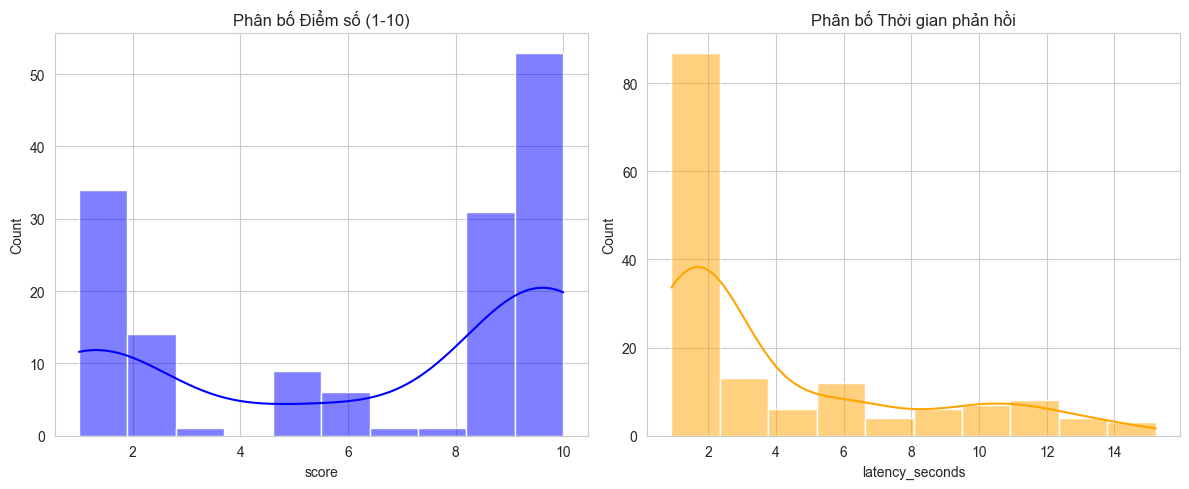


🔴 CÁC CÂU ĐIỂM THẤP (<7):
                                              question  score
1    Em là tân sinh viên K2025 trúng tuyển ngành Kỹ...    1.0
2    Mức điểm TOEIC 4 kỹ năng 800 điểm sẽ được xét ...    5.0
4    Chứng chỉ Tiếng Nhật JLAN J4 đạt 91 điểm được ...    1.0
6    Nghỉ học không phép sẽ bị trừ bao nhiêu điểm r...    1.0
10   cho e hỏi đkmh đợt bổ sung hk1 năm nay là ngày...    2.0
..                                                 ...    ...
144              sv clc bảo vệ khóa luận chưa làm nckh    1.0
145               đang thử thách hv đk học 2 bằng dc k    1.0
146              bị khiển trách có dc loại xuất sắc ko    2.0
148                             lớp sv xuất sắc cần gì    1.0
149  đkmh đợt 2 từ ngày 12/8/2025 là cho đh đại trà...    1.0

[64 rows x 2 columns]

CÁC CÂU ĐIỂM CAO (>=8):
                                              question  score
0    Học phí học lại cấp độ Anh ngữ của chương trìn...   10.0
3    Sinh viên khóa 2024 nộp chứng chỉ IELTS 5.5 sẽ...   

In [9]:
df = pd.read_csv(CSV_CHECKPOINT, encoding='utf-8-sig')
print("="*60)
print(f"📊 BẢNG TỔNG KẾT RAG: {model_name}")
print("="*60)
print(f"📉 Điểm Trung Bình: {df['score'].mean():.2f}/10")
print(f"⏱️ Thời gian TB: {df['latency_seconds'].mean():.2f} giây")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['score'], bins=10, ax=axes[0], color='blue', kde=True)
axes[0].set_title("Phân bố Điểm số (1-10)")
sns.histplot(df['latency_seconds'], bins=10, ax=axes[1], color='orange', kde=True)
axes[1].set_title("Phân bố Thời gian phản hồi")
plt.tight_layout()
plt.show()

print("\n🔴 CÁC CÂU ĐIỂM THẤP (<7):")
print(df[df['score'] < 7][['question', 'score']])

print('\nCÁC CÂU ĐIỂM CAO (>=8):')
print(df[df['score'] >= 7][['question', 'score']])

summary_stats = df.agg({
    'score': ['mean', 'median', 'std', 'min', 'max'],
    'latency_seconds': ['mean', 'median', 'std', 'min', 'max']
}).round(2)
print("\n📊 BẢNG TỔNG KẾT ĐÁNH GIÁ")
print("="*60)
print(summary_stats)
